Importing the dependencies

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

Loading hte MNIST Data

In [26]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [27]:
type(X_train)

numpy.ndarray

In [28]:
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Training Data = 60 000 Images

Test Data = 10 000 Images

Image Dimension --> 28 x 28

Grayscale Image --> 1 channel

In [29]:
# Printing the 10th image
print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [30]:
print(X_train[10].shape)

(28, 28)


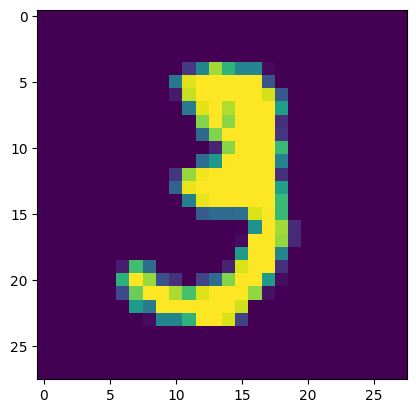

3


In [31]:
# Displaying the image
plt.imshow(X_train[10])
plt.show()

# Print the corresponding label
print(Y_train[10])

Image Labels

In [32]:
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [33]:
# Unique values in Y_Train
print(np.unique(Y_train))

print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [34]:
# Scaling the values

X_train = X_train/255
X_test = X_test/255

In [35]:
print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building the Neural Network

In [36]:
# Setting up the layers of the Neural Network

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

/home/mithranes/Documents/old/Machine Learning/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
# Compiling the neural network

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'] )

In [38]:
# Training the neural network

model.fit(X_train, Y_train, epochs=10)

Epoch 1/10


2025-12-11 10:07:56.184129: I external/local_xla/xla/service/service.cc:163] XLA service 0x711898017c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-11 10:07:56.184143: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-12-11 10:07:56.209571: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-11 10:07:56.326229: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2025-12-11 10:07:56.352684: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-11 10:07:57.

 104/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4835 - loss: 1.6754

I0000 00:00:1765433278.767058   11987 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9125 - loss: 0.3034
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9580 - loss: 0.1419
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9694 - loss: 0.1026
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9748 - loss: 0.0809
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9799 - loss: 0.0663
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9832 - loss: 0.0554
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 982us/step - accuracy: 0.9855 - loss: 0.0472
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 981us/step - accuracy: 0.9880 - loss: 0.0403
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9890 - loss: 0.0363  
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 966us/step - accuracy: 0.9901 - loss: 0.0310


Training data accuracy 99%

**Accuracy on Test Data**

In [39]:
lost, accuracy = model.evaluate(X_test, Y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9689 - loss: 0.1274
0.9689000248908997


Test data accuracy 96.8%

In [40]:
print(X_test.shape)

(10000, 28, 28)


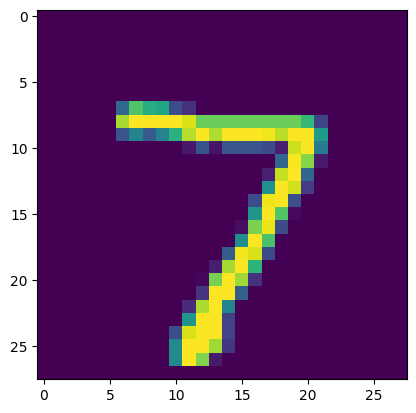

7


In [47]:
# Displaying the first test data point
plt.imshow(X_test[0])
plt.show()

print(Y_test[0])

In [48]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [49]:
print(Y_pred.shape)

(10000, 10)


In [50]:
print(Y_pred[0])

[9.6538504e-05 5.7768030e-04 7.8051756e-03 8.8733953e-01 1.5982409e-06
 6.7479603e-05 1.8551176e-12 9.9999845e-01 3.3512039e-03 9.1316384e-01]


model.predict gives the prediction probabilityof each class

In [52]:
# Converting the prediction probabilities to class labels
label_first = np.argmax(Y_pred[0])
print(label_first)

7


In [55]:
Y_pred_label = [np.argmax(i) for i in Y_pred]
print(Y_pred_label)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

Y_test --> True Labels

Y_pred_label --> Predicted

Confusion Matrix

In [56]:
confusion_matrix = confusion_matrix(Y_test, Y_pred_label)

In [57]:
print(confusion_matrix)

tf.Tensor(
[[ 960    0    1    3    3    2    2    2    2    5]
 [   0 1114    3    5    0    0    4    2    7    0]
 [   3    0 1007   10    2    0    3    3    4    0]
 [   0    0    5  987    1    2    0    3    4    8]
 [   0    1    4    1  968    1    1    1    2    3]
 [   3    0    0   33    3  842    2    0    6    3]
 [   5    2    1    3    8    8  931    0    0    0]
 [   1    3    9    9    6    1    1  984    1   13]
 [   1    0    4   20    5    3    2    4  931    4]
 [   0    3    0    8   18    3    1    4    7  965]], shape=(10, 10), dtype=int32)


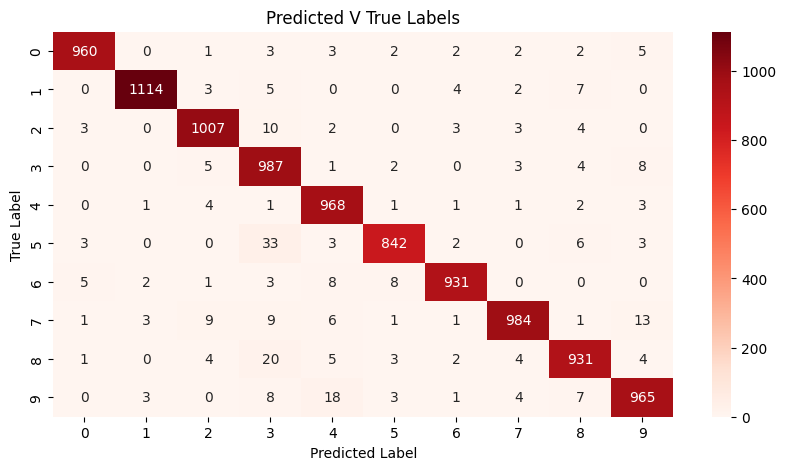

In [62]:
plt.figure(figsize=(10,5))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap="Reds")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Predicted V True Labels')
plt.show()

Predictive System

In [64]:
input_image_path = 'Dataset/MNIST_digit.png'

In [65]:
input_image = cv2.imread(input_image_path)

In [66]:
type(input_image)

numpy.ndarray

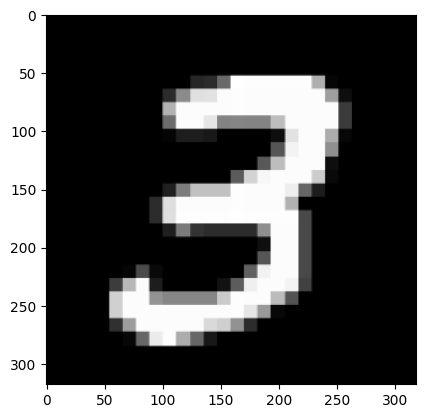

In [67]:
plt.imshow(input_image)

In [71]:
input_image.shape

(318, 318, 3)

In [72]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

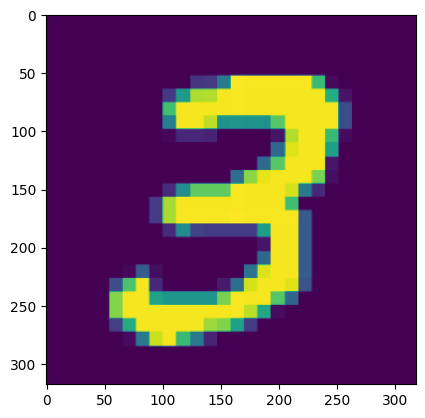

In [73]:
plt.imshow(grayscale)

In [74]:
grayscale.shape

(318, 318)

In [75]:
input_image_resized = cv2.resize(grayscale, (28,28))

In [76]:
input_image_resized.shape

(28, 28)

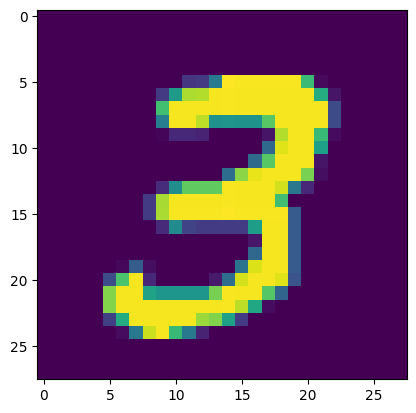

In [77]:
plt.imshow(input_image_resized)

In [78]:
input_image_resized = input_image_resized/255

In [79]:
image_reshaped = np.reshape(input_image_resized, [1,28,28])

In [80]:
input_prediction = model.predict (image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
[[8.6937263e-11 1.9666138e-06 2.3830710e-04 1.0000000e+00 1.2104843e-12
  1.3097094e-02 2.8316266e-23 6.0576969e-03 8.4140474e-01 9.1771924e-01]]


In [81]:
input_pred_label = np.argmax(input_prediction)

In [82]:
print(input_pred_label)

3


**Predictive System**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
The Image Digit is recognized as  3


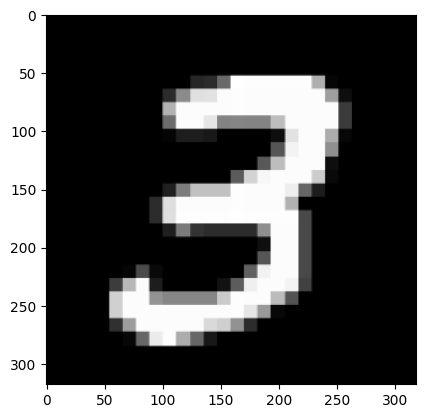

In [84]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

plt.imshow(input_image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resized = cv2.resize(grayscale, (28,28))

input_image_resized = input_image_resized/255

image_reshaped = np.reshape(input_image_resized, [1,28,28])

input_prediction = model.predict (image_reshaped)

input_pred_label = np.argmax(input_prediction)

print('The Image Digit is recognized as ', input_pred_label)